In [37]:
!pip install xgboost


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\pc\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


# 04. Model 2: Cancer Staging (Multi-class Classification)

This notebook handles **Model 2**, which predicts the **Cancer Stage** (`Stage I`, `Stage II`, `Stage III`, `Stage IV`) for patients diagnosed with lung cancer.

### Pipeline:
1. Environment & Library Setup
2. Data Filtering & Target Definition
3. Feature Selection & Categorical Encoding
4. Dataset Splitting & Feature Scaling
5. Multi-model Training & Evaluation
6. Performance Metrics & Visualizations
7. Model Artifacts Persistence

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Data Loading & Filtering Positive Cancer Cases

We extract cases where `cancer_presence == 1` and filter out non-cancer rows to avoid data leakage during stage classification.

In [39]:
df = pd.read_csv('LungCanC2024_Dataset.csv')

target_m2 = "cancer_stage"
df_staging = df[(df['cancer_presence'] == 1) & (df[target_m2] != 'No Cancer')].copy()

print(f"Total Diagnosed Patients for Staging: {df_staging.shape[0]}")

Total Diagnosed Patients for Staging: 122302


## 2. Feature Selection & Categorical Encoding

We select the 18 specific clinical, genomic, and imaging features assigned for Model 2 (`features_m2`) and encode categorical inputs.

In [40]:

features_m2 = [
    "nodule_size_mm", "nodule_texture", "HU_mean", "HU_std",
    "GLCM_contrast", "GLCM_correlation", "PET_SUVmax", "PET_SUVmean",
    "patient_age", "patient_gender", "smoking_history", "family_history",
    "tumor_location", "EGFR_mutation_status", "KRAS_mutation_status",
    "ALK_fusion_status", "PD-L1_expression_level", "tumor_mutational_burden"
]


df_staging = df_staging.dropna(subset=[target_m2])

X = df_staging[features_m2]
y = df_staging[target_m2]


X_encoded = pd.get_dummies(X, drop_first=True)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

## 3. Train / Test Split & Feature Scaling

Splitting dataset into 80% training and 20% testing sets using stratified sampling, followed by standard scaling.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Set Shape:", X_train_scaled.shape)
print("Testing Set Shape:", X_test_scaled.shape)

Training Set Shape: (97841, 19)
Testing Set Shape: (24461, 19)


## 4. Multi-Model Training & Performance Comparison

Training multiple classifiers (Decision Tree, Random Forest, Extra Trees, XGBoost) to select the model with highest accuracy and weighted F1-score.

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss')
}

best_model = None
best_accuracy = 0
best_model_name = ""

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"📌 {name} -> Accuracy: {acc * 100:.2f}% | F1-Score: {f1:.4f}")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_model_name = name

print(f"\n🏆 Best Model Selected: {best_model_name} (Accuracy: {best_accuracy * 100:.2f}%)")

📌 Decision Tree -> Accuracy: 26.66% | F1-Score: 0.2668
📌 Random Forest -> Accuracy: 29.96% | F1-Score: 0.2573
📌 Extra Trees -> Accuracy: 29.88% | F1-Score: 0.2608
📌 XGBoost -> Accuracy: 29.68% | F1-Score: 0.2517

🏆 Best Model Selected: Random Forest (Accuracy: 29.96%)


## 5. Evaluation & Visualizations for Best Model

Generating Classification Report, Confusion Matrix, and Feature Importances for the selected champion model.

=== Classification Report ===
              precision    recall  f1-score   support

     Stage I       0.24      0.10      0.14      5662
    Stage II       0.30      0.45      0.36      7482
   Stage III       0.31      0.45      0.37      7551
    Stage IV       0.22      0.01      0.01      3766

    accuracy                           0.30     24461
   macro avg       0.27      0.25      0.22     24461
weighted avg       0.28      0.30      0.26     24461



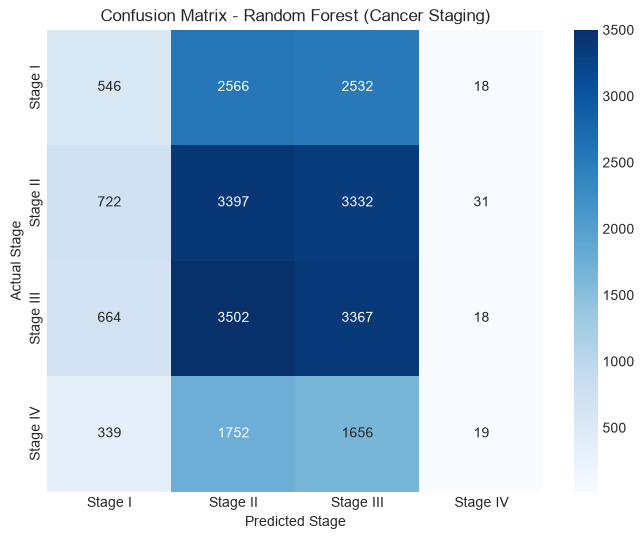

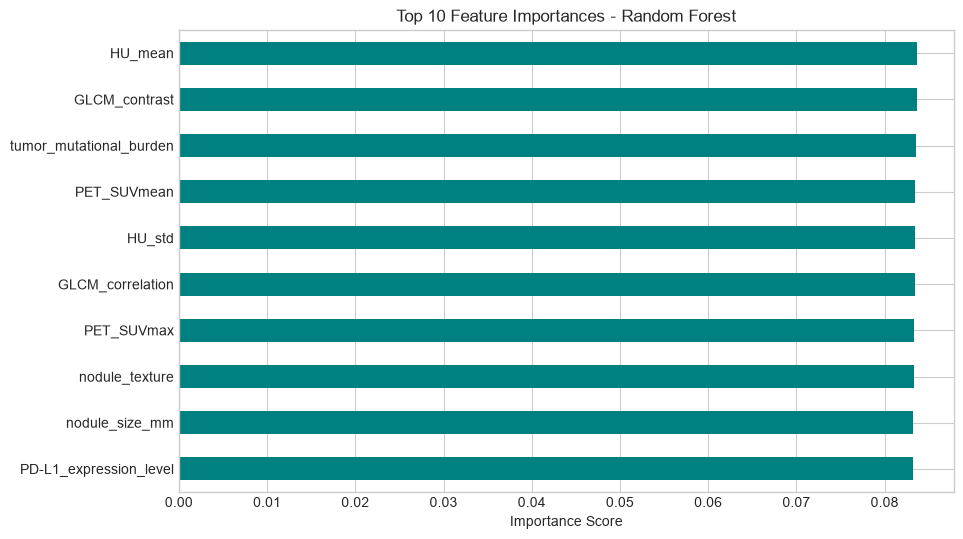

In [43]:
y_best_pred = best_model.predict(X_test_scaled)

print("=== Classification Report ===")
print(classification_report(y_test, y_best_pred, target_names=le.classes_))

# Confusion Matrix Plot
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name} (Cancer Staging)')
plt.xlabel('Predicted Stage')
plt.ylabel('Actual Stage')
plt.show()

# Feature Importances Plot
if hasattr(best_model, 'feature_importances_'):
    plt.figure(figsize=(10, 6))
    importances = pd.Series(best_model.feature_importances_, index=X_encoded.columns)
    importances.nlargest(10).plot(kind='barh', color='teal')
    plt.title(f'Top 10 Feature Importances - {best_model_name}')
    plt.xlabel('Importance Score')
    plt.gca().invert_yaxis()
    plt.show()

## 6. Saving Model Artifacts

Exporting trained model, scaler, and label encoder for integration and deployment.

In [45]:
joblib.dump(best_model, 'cancer_staging_model.joblib')
joblib.dump(scaler, 'staging_scaler.joblib')
joblib.dump(le, 'staging_label_encoder.joblib')

print("Model and preprocessing artifacts saved successfully!")

Model and preprocessing artifacts saved successfully!
